# Topic 1B: Pandas for Financial Data Wrangling
**Module 1 - Introduction to Machine Learning in Python**

This notebook demonstrates Pandas operations for financial data:
loading, cleaning, merging, time-series operations, and GroupBy aggregation.


## Setup
Download the LendingClub dataset from Kaggle:
https://www.kaggle.com/datasets/wordsforthewise/lending-club

Or use the sample data generated below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Generate sample loan data (replace with real LendingClub data if available)
np.random.seed(42)
n = 10000
df = pd.DataFrame({
    'loan_id': range(n),
    'loan_amnt': np.random.lognormal(9.5, 0.5, n).round(0),
    'int_rate': np.random.uniform(5, 25, n).round(2),
    'annual_income': np.random.lognormal(11, 0.7, n).round(0),
    'dti': np.random.uniform(0, 40, n).round(2),
    'grade': np.random.choice(['A','B','C','D','E','F','G'], n, p=[0.15,0.25,0.25,0.15,0.10,0.06,0.04]),
    'home_ownership': np.random.choice(['RENT','MORTGAGE','OWN','OTHER'], n, p=[0.40,0.42,0.15,0.03]),
    'purpose': np.random.choice(['debt_consolidation','credit_card','home_improvement','major_purchase','other'], n, p=[0.40,0.25,0.15,0.10,0.10]),
    'emp_length': np.random.choice([np.nan,0,1,2,3,5,7,10], n, p=[0.08,0.05,0.10,0.12,0.15,0.15,0.15,0.20]),
    'issue_d': pd.date_range('2018-01-01', periods=n, freq='3H'),
})

# Create default column (8% default rate, higher for worse grades)
grade_default_prob = {'A':0.03, 'B':0.05, 'C':0.08, 'D':0.12, 'E':0.18, 'F':0.25, 'G':0.35}
df['default'] = df['grade'].map(grade_default_prob).apply(lambda p: np.random.binomial(1, p))

# Introduce some missing values
df.loc[np.random.choice(n, 500, replace=False), 'annual_income'] = np.nan
df.loc[np.random.choice(n, 300, replace=False), 'dti'] = np.nan

print(f'Shape: {df.shape}')
print(f'Default rate: {df["default"].mean():.4f}')
df.head()


Shape: (10000, 11)
Default rate: 0.1006


C:\Users\TeresaZhu\AppData\Local\Temp\ipykernel_29136\1810997862.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'issue_d': pd.date_range('2018-01-01', periods=n, freq='3H'),


,loan_id,loan_amnt,int_rate,annual_income,dti,grade,home_ownership,purpose,emp_length,issue_d,default
0,0,17126.0,11.43,42804.0,5.79,B,MORTGAGE,home_improvement,3.0,2018-01-01 00:00:00,0
1,1,12467.0,7.06,NaN,32.13,D,MORTGAGE,debt_consolidation,3.0,2018-01-01 03:00:00,1
2,2,18469.0,6.44,85085.0,12.30,A,MORTGAGE,credit_card,2.0,2018-01-01 06:00:00,0
3,3,28610.0,6.89,18128.0,30.86,E,OWN,home_improvement,NaN,2018-01-01 09:00:00,0
4,4,11884.0,16.66,49638.0,25.90,C,OWN,home_improvement,7.0,2018-01-01 12:00:00,0


## 1. Data Inspection


In [2]:
# Basic inspection - always start with these 3 commands
print('=== INFO ===')
print(df.info())
print('\n=== DESCRIBE ===')
print(df.describe().round(2))
print('\n=== MISSING DATA ===')
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)
print(f'\nTotal rows with any missing: {df.isnull().any(axis=1).sum()}')


=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   loan_id         10000 non-null  int64         
 1   loan_amnt       10000 non-null  float64       
 2   int_rate        10000 non-null  float64       
 3   annual_income   9500 non-null   float64       
 4   dti             9700 non-null   float64       
 5   grade           10000 non-null  object        
 6   home_ownership  10000 non-null  object        
 7   purpose         10000 non-null  object        
 8   emp_length      9185 non-null   float64       
 9   issue_d         10000 non-null  datetime64[ns]
 10  default         10000 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(2), object(3)
memory usage: 859.5+ KB
None

=== DESCRIBE ===
        loan_id  loan_amnt  int_rate  annual_income      dti  emp_length  \
count  10000.00   100

## 2. Missing Data Report


In [3]:
missing_report = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(2),
    'dtype': df.dtypes
}).sort_values('missing_pct', ascending=False)

missing_report = missing_report[missing_report['missing_pct'] > 0]
print('Missing Data Report:')
print(missing_report)


Missing Data Report:
               missing_count  missing_pct    dtype
emp_length               815         8.15  float64
annual_income            500         5.00  float64
dti                      300         3.00  float64


## 3. Default Rate by Segment (GroupBy)


In [4]:
# Default rate by grade
by_grade = df.groupby('grade').agg(
    count=('default', 'count'),
    default_rate=('default', 'mean'),
    avg_income=('annual_income', 'mean'),
    avg_int_rate=('int_rate', 'mean'),
    avg_loan=('loan_amnt', 'mean')
).round(4)
print('Default Rate by Grade:')
print(by_grade)

print('\nDefault Rate by Home Ownership:')
print(df.groupby('home_ownership')['default'].agg(['count', 'mean']).round(4))

print('\nDefault Rate by Purpose:')
print(df.groupby('purpose')['default'].agg(['count', 'mean']).sort_values('mean', ascending=False).round(4))


Default Rate by Grade:
       count  default_rate  avg_income  avg_int_rate    avg_loan
grade                                                           
A       1491        0.0174  76910.7376       14.9974  15385.7854
B       2513        0.0569  77210.6728       15.1348  14874.0740
C       2491        0.0855  75255.9626       15.2473  15155.0161
D       1531        0.1110  76733.7383       14.8628  15148.6728
E        997        0.1805  76014.3410       15.4456  15513.4644
F        604        0.2434  71426.7055       15.5085  14903.0828
G        373        0.3405  70281.3567       14.8235  15116.3807

Default Rate by Home Ownership:
                count    mean
home_ownership               
MORTGAGE         4232  0.0952
OTHER             296  0.1047
OWN              1488  0.1028
RENT             3984  0.1052

Default Rate by Purpose:
                    count    mean
purpose                          
credit_card          2516  0.1049
other                 940  0.1043
debt_consolidatio

## 4. Time-Series Operations


C:\Users\TeresaZhu\AppData\Local\Temp\ipykernel_29136\1225534304.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = ts.resample('M')['loan_amnt'].sum()
C:\Users\TeresaZhu\AppData\Local\Temp\ipykernel_29136\1225534304.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_default = ts.resample('M')['default'].mean()


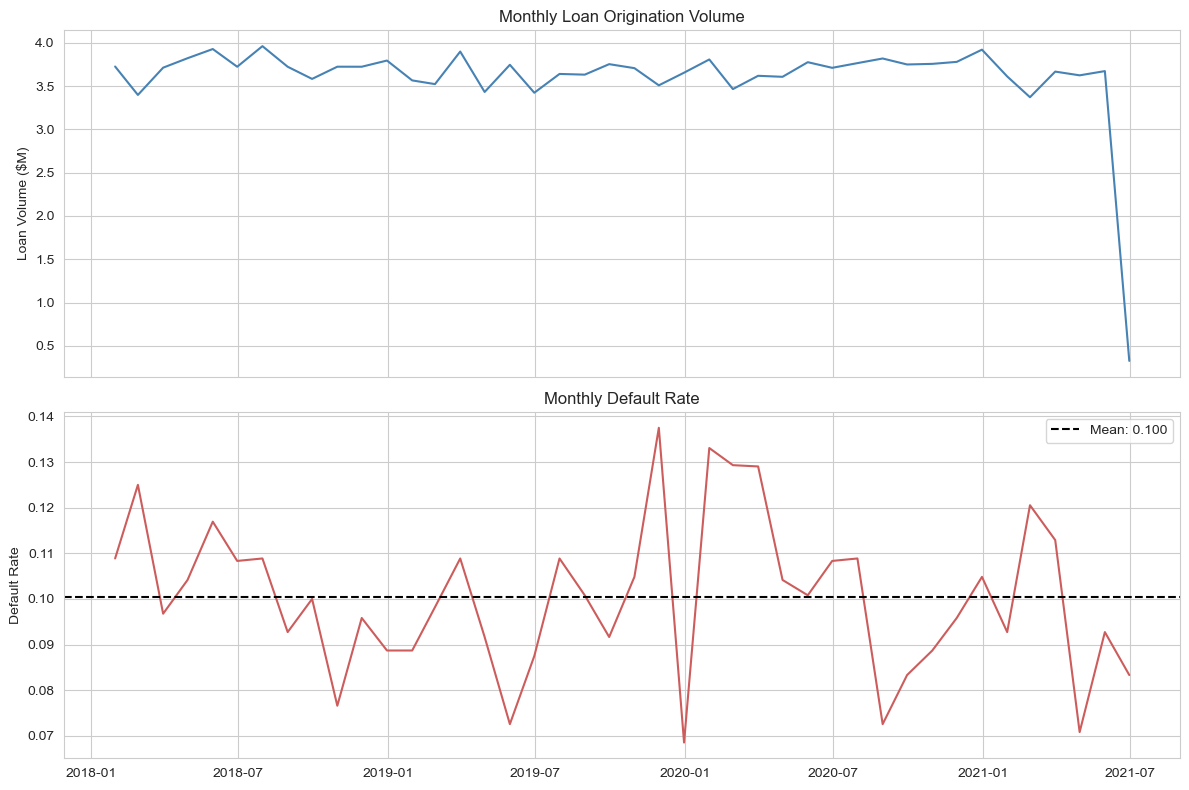

In [5]:
# Set date index for time-series operations
ts = df.set_index('issue_d')

# Monthly loan volume
monthly_volume = ts.resample('M')['loan_amnt'].sum()

# Monthly default rate
monthly_default = ts.resample('M')['default'].mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(monthly_volume / 1e6, color='steelblue')
ax1.set_ylabel('Loan Volume ($M)')
ax1.set_title('Monthly Loan Origination Volume')

ax2.plot(monthly_default, color='indianred')
ax2.axhline(y=monthly_default.mean(), color='black', linestyle='--', label=f'Mean: {monthly_default.mean():.3f}')
ax2.set_ylabel('Default Rate')
ax2.set_title('Monthly Default Rate')
ax2.legend()

plt.tight_layout()
plt.show()


## 5. Merging Tables (Simulating Bureau Data)


In [6]:
# Create synthetic bureau data
np.random.seed(42)
bureau = pd.DataFrame({
    'loan_id': np.repeat(df['loan_id'].values, np.random.randint(0, 8, n)),
})
bureau['bureau_credit_amount'] = np.random.lognormal(10, 1, len(bureau)).round(0)
bureau['bureau_overdue_days'] = np.random.exponential(10, len(bureau)).round(0)
bureau['bureau_credit_active'] = np.random.choice(['Active', 'Closed'], len(bureau), p=[0.4, 0.6])

print(f'Bureau records: {len(bureau)}')
print(f'Unique loan_ids in bureau: {bureau["loan_id"].nunique()}')

# IMPORTANT: Aggregate BEFORE merging (one-to-many join problem)
bureau_agg = bureau.groupby('loan_id').agg(
    num_bureau_records=('bureau_credit_amount', 'count'),
    avg_bureau_credit=('bureau_credit_amount', 'mean'),
    max_overdue_days=('bureau_overdue_days', 'max'),
    num_active_credits=('bureau_credit_active', lambda x: (x == 'Active').sum()),
).reset_index()

print(f'\nAggregated bureau shape: {bureau_agg.shape}')

# Left join: keep all loans, add bureau features where available
df_merged = df.merge(bureau_agg, on='loan_id', how='left')

# Fill NaN for loans with no bureau records
df_merged['num_bureau_records'] = df_merged['num_bureau_records'].fillna(0)

print(f'Merged shape: {df_merged.shape}')
print(f'Loans with no bureau data: {(df_merged["num_bureau_records"] == 0).sum()}')


Bureau records: 35003
Unique loan_ids in bureau: 8735

Aggregated bureau shape: (8735, 5)
Merged shape: (10000, 15)
Loans with no bureau data: 1265


## 6. Feature Correlation with Target


In [7]:
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns
correlations = df_merged[numeric_cols].corrwith(df_merged['default']).abs().sort_values(ascending=False)
print('Features most correlated with default:')
print(correlations.head(10).round(4))


Features most correlated with default:
default               1.0000
loan_amnt             0.0128
num_bureau_records    0.0114
max_overdue_days      0.0096
annual_income         0.0066
dti                   0.0066
emp_length            0.0056
loan_id               0.0050
avg_bureau_credit     0.0046
num_active_credits    0.0025
dtype: float64
